<a href="https://colab.research.google.com/github/JCSR2022/challenge3-data-science-Alura/blob/main/data/Data_Preprocessing_Stage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Telecom X – Customer Churn Prediction

## Data Preprocessing Stage

### Project Context

Telecom X faces a critical business challenge: **customer churn**. Customer cancellations directly impact revenue stability, increase acquisition costs, and affect long-term growth.

The objective of this project is to develop **Machine Learning models capable of predicting which customers are most likely to cancel their services** before churn occurs.

This stage represents the transition from **exploratory data analysis to predictive modeling**, where the focus shifts to preparing the dataset to ensure reliable, interpretable, and high-performance models.

Some of this work was made on the Challenge 2 , but in this ocasion the focus will be on billding a pipeline that allow take this process to production.

---

# 🧠 Data Preprocessing Pipeline

The preprocessing stage prepares the raw dataset for Machine Learning modeling by cleaning, transforming, and selecting relevant features.


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin



import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
from seaborn.palettes import color_palette


import warnings
#warnings.filterwarnings("ignore")

In [47]:
# -----------------------------
# 0. Visual configuration
# -----------------------------
sns.set_theme(style="white", font_scale=1.1)

#color_palette_options = ["viridis","rocket","Blues","crest","flare","magma","rocket_r"]
curr_color = "crest"
CMAP = sns.color_palette(curr_color, as_cmap=True)

# to avoid to dark or to white colors
COLOR_MIN = 0.2
COLOR_MAX = 0.8
def value_to_color(v, vmin, vmax):
    norm = Normalize(vmin, vmax)
    return CMAP(COLOR_MIN + (COLOR_MAX - COLOR_MIN) * norm(v))


#style must be one of white, dark, whitegrid, darkgrid, ticks
sns.set_theme(
    style="whitegrid",
    palette=curr_color,
    font="sans-serif",
    font_scale=1.1
)


#For all random
my_random_seed = 42



def show_table(df, column=None):

    if column:
        df = df.sort_values(by=column, ascending=False)

        vmin = df[column].min()
        vmax = df[column].max()

        def style_cell(v):
            r, g, b, _ = value_to_color(v, vmin, vmax)
            return f'background-color: rgb({int(r*255)}, {int(g*255)}, {int(b*255)})'

        styled = df.style.applymap(style_cell, subset=[column])

    else:
        styled = df.style

    return (
        styled
        .format(precision=2)
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th",
             "props": [
                 ("font-weight", "bold"),
                 ("text-align", "center")
             ]}
        ])
    )



def barplot(df, x, y, title, y_unit=None, x_unit=None):

    df = df.sort_values(by=y, ascending=False)

    norm = Normalize(df[y].min(), df[y].max())

    colors = [ CMAP(COLOR_MIN + (COLOR_MAX - COLOR_MIN) * norm(v))for v in df[y] ]

    fig, ax = plt.subplots(figsize=(10,6))

    bars = ax.bar(df[x], df[y], color=colors)

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(x + (f" [{x_unit}]" if x_unit else ""))
    ax.set_ylabel(y + (f" [{y_unit}]" if y_unit else ""))


    offset = df[y].max() * 0.01

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + offset,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

    sns.despine()
    plt.tight_layout()

    return fig


def distribution_plot(df, x, title=None, bins=None, x_unit=None):

    data = df[x].dropna()

    # -------- estadísticas --------
    mean_val = data.mean()
    median_val = data.median()

    # -------- bins automáticos (Freedman–Diaconis) --------
    if bins is None:
        q75, q25 = np.percentile(data, [75, 25])
        iqr = q75 - q25
        n = len(data)

        bin_width = 2 * iqr / n**(1/3)

        if bin_width > 0:
            bins = int((data.max() - data.min()) / bin_width)
        else:
            bins = 20

    # -------- colores consistentes --------
    hist_color = CMAP(0.55)
    kde_color = CMAP(0.9)
    box_color = CMAP(0.55)
    edge_color = CMAP(0.9)

    mean_color = CMAP(0.95)
    median_color = CMAP(0.75)

    # -------- figura --------
    fig, (ax_hist, ax_box) = plt.subplots(
        2,
        1,
        figsize=(8,5),
        gridspec_kw={"height_ratios": [4, 1]},
        sharex=True
    )

    # -------- Histograma --------
    sns.histplot(
        data=data,
        bins=bins,
        kde=True,
        color=hist_color,
        edgecolor="white",
        ax=ax_hist
    )

    if ax_hist.lines:
        ax_hist.lines[0].set_color(kde_color)
        ax_hist.lines[0].set_linewidth(2)

    # -------- líneas de media y mediana --------
    ax_hist.axvline(mean_val, color=mean_color, linestyle="--", linewidth=2)
    ax_hist.axvline(median_val, color=median_color, linestyle="-", linewidth=2)

    # -------- texto con estadísticas --------
    stats_text = (
        f"Mean: {mean_val:.2f}\n"
        f"Median: {median_val:.2f}"
        + (f" {x_unit}" if x_unit else "")
    )

    ax_hist.text(
        0.98,
        0.95,
        stats_text,
        transform=ax_hist.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85,
            edgecolor="none"
        )
    )

    ax_hist.set_title(
        title if title else f'Distribution of {x}',
        fontsize=14,
        weight="bold"
    )

    ax_hist.set_ylabel("Count")

    # -------- Boxplot --------
    sns.boxplot(
        x=data,
        ax=ax_box,
        color=box_color,
        width=0.4,
        fliersize=3,
        linewidth=1.5
    )

    for line in ax_box.lines:
        line.set_color(edge_color)
        line.set_linewidth(1.5)

    ax_box.set_xlabel(x + (f" [{x_unit}]" if x_unit else ""))
    ax_box.set_ylabel("")

    sns.despine(ax=ax_hist)
    sns.despine(ax=ax_box)

    plt.tight_layout()

    return fig


def inspect_preprocessor(preprocessor, X):
    Xt = preprocessor.fit_transform(X)
    return pd.DataFrame(
        Xt if not hasattr(Xt, "toarray") else Xt.toarray(),
        columns=preprocessor.get_feature_names_out()
    )

In [9]:
# ================================
# 1. Load Data
# ================================

url_data = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"
data_raw = pd.read_json(url_data)
data = pd.json_normalize(data_raw.to_dict(orient="records"))

In [10]:
# ================================
# 2. Data Cleaning
# ================================

# keep valid target labels
data = data[data["Churn"].isin(["Yes", "No"])]

# convert numeric column
data["account.Charges.Total"] = pd.to_numeric(data["account.Charges.Total"], errors="coerce")

# remove invalid rows
data = data.dropna(subset=["account.Charges.Total"])

# encode target
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})

In [11]:
# ================================
# 3. Feature / Target Split
# ================================

X = data.drop("Churn", axis=1)
y = data["Churn"]

In [12]:

# ================================
# 4. Custom Transformer
# ================================

class BinaryMapper(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.binary_map = {
            "customer.gender": {"Female": 0, "Male": 1},
            "customer.Partner": {"No": 0, "Yes": 1},
            "customer.Dependents": {"No": 0, "Yes": 1},
            "phone.PhoneService": {"No": 0, "Yes": 1},
            "phone.MultipleLines": {"No": 0, "Yes": 1, "No phone service": 0},
            "internet.OnlineSecurity": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.OnlineBackup": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.DeviceProtection": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.TechSupport": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.StreamingTV": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.StreamingMovies": {"No": 0, "Yes": 1, "No internet service": 0},
            "account.PaperlessBilling": {"No": 0, "Yes": 1}
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # remove ID
        X = X.drop("customerID", axis=1)

        for col, mapping in self.binary_map.items():
            X[col] = X[col].map(mapping)

        X.rename(columns=lambda x: "_".join(x.split('.')[1:]), inplace=True)

        return X

In [14]:
my_binary_mapper = BinaryMapper()
X_trans = my_binary_mapper.fit_transform(X)

In [16]:
# ================================
# 5. Feature Groups
# ================================

binary_features =['gender','SeniorCitizen','Partner','Dependents',
'PhoneService','MultipleLines',
'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
'StreamingTV','StreamingMovies',
'PaperlessBilling']

categorical_onehot =['InternetService','Contract','PaymentMethod']

numeric_features = ['tenure', 'Charges_Monthly', 'Charges_Total']


In [19]:
X_trans[numeric_features].corr()

,tenure,Charges_Monthly,Charges_Total
tenure,1.000000,0.246862,0.825880
Charges_Monthly,0.246862,1.000000,0.651065
Charges_Total,0.825880,0.651065,1.000000


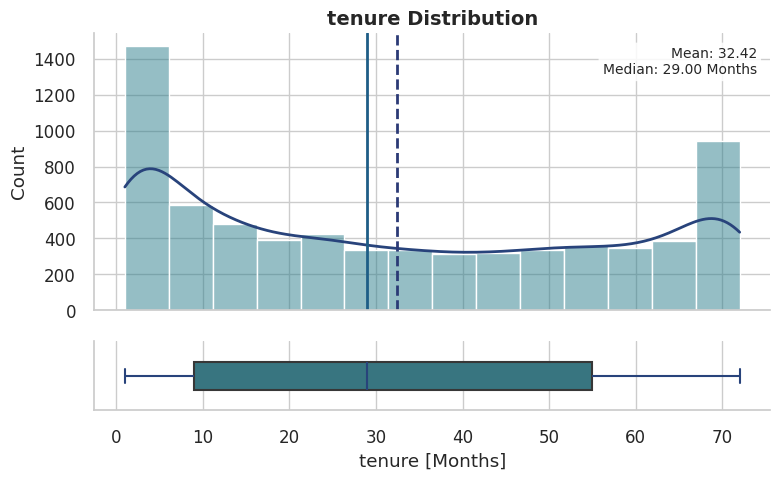

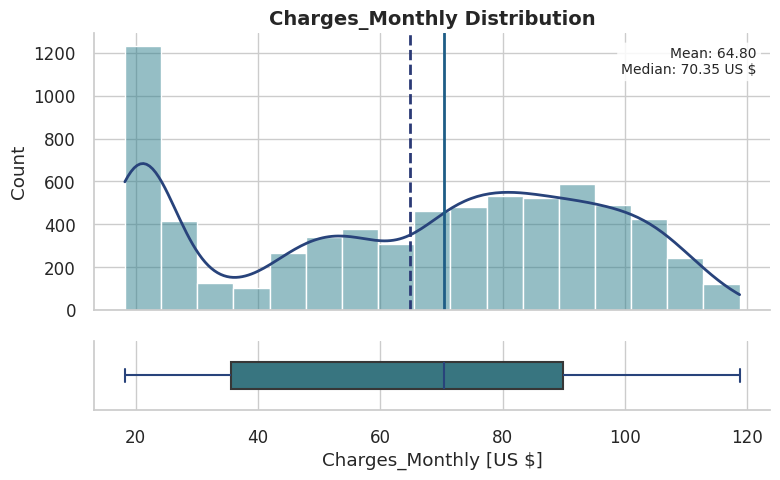

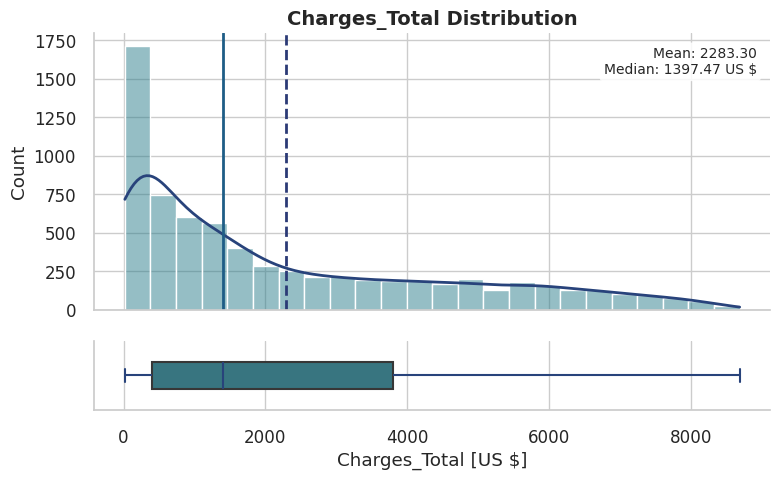

In [27]:
features_units = {'tenure':'Months', 'Charges_Monthly':'US $', 'Charges_Total':'US $'}
for col in numeric_features:
  distribution_plot(X_trans[[col]], col, f'{col} Distribution', x_unit=features_units[col]).show()

In [35]:
from sklearn.preprocessing import PowerTransformer

def inspect_preprocessor(preprocessor, X):
    Xt = preprocessor.fit_transform(X)
    return pd.DataFrame(
        Xt if not hasattr(Xt, "toarray") else Xt.toarray(),
        columns=preprocessor.get_feature_names_out()
    )


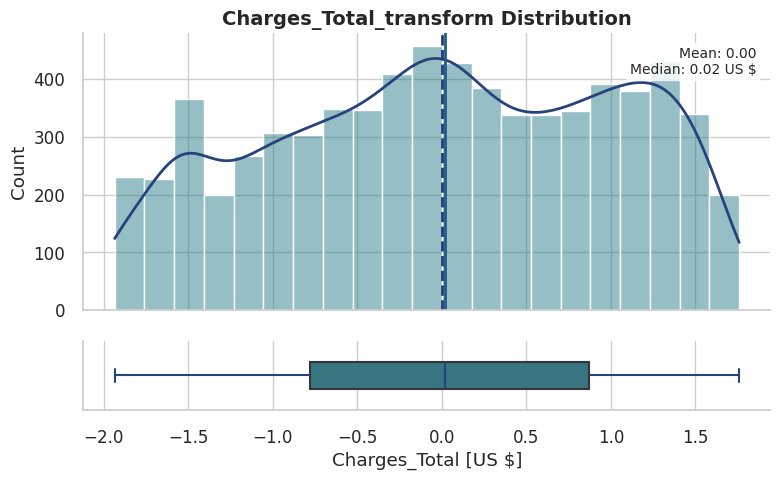

In [59]:

Charges_Total_PowerTransformer = PowerTransformer(method='box-cox',standardize=True)
Charges_Total_transfor = Charges_Total_PowerTransformer.fit_transform(X_trans[['Charges_Total']])

df_Charges_Total_frec=  inspect_preprocessor(Charges_Total_PowerTransformer, X_trans[['Charges_Total']])
distribution_plot(df_Charges_Total_frec, 'Charges_Total', 'Charges_Total_transform Distribution', x_unit='US $').show()

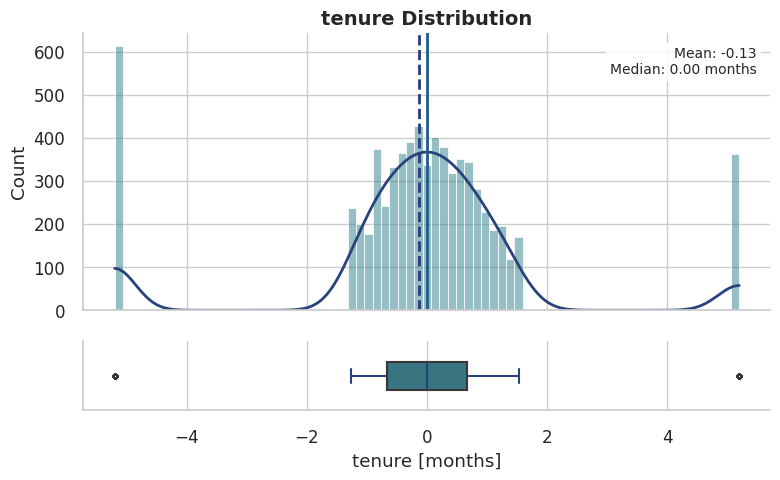

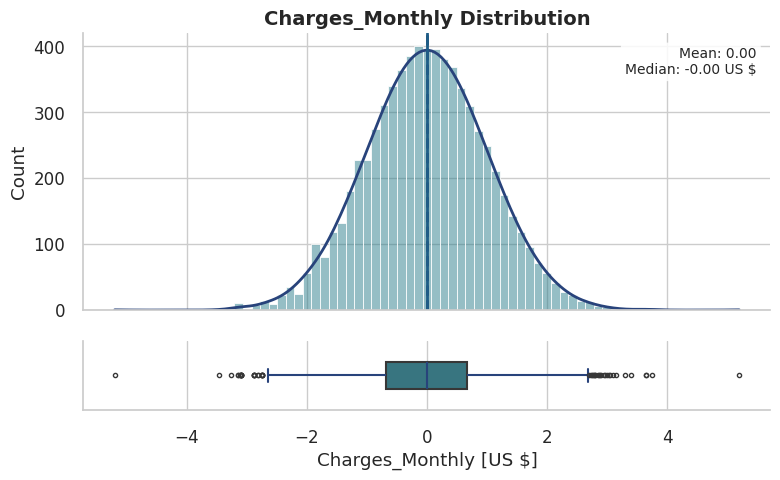

In [65]:
from sklearn.preprocessing import QuantileTransformer

quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=my_random_seed)


#tenure_transform =tenure_quantile_transformer.fit_transform(X_trans[['tenure']])
df_tenure_frec=  inspect_preprocessor(quantile_transformer, X_trans[['tenure']])
distribution_plot(df_tenure_frec, 'tenure', 'tenure Distribution', x_unit='months').show()

#Charges_Monthly_transform = tenure_quantile_transformer.fit_transform(X_trans[['Charges_Monthly']])
df_Charges_Monthly_frec=  inspect_preprocessor(quantile_transformer, X_trans[['Charges_Monthly']])
distribution_plot(df_Charges_Monthly_frec, 'Charges_Monthly', 'Charges_Monthly Distribution', x_unit='US $').show()

In [73]:
import pandas as pd

# Para unirlos uno debajo del otro (Verticalmente)
#df_final = pd.concat([df_Charges_Monthly_frec, df_tenure_frec, df_Charges_Total_frec])

# Para unirlos de lado (Horizontalmente, alineando por índice)
df_final_side = pd.concat([df_Charges_Monthly_frec, df_tenure_frec, df_Charges_Total_frec], axis=1)
df_final_side.corr()

,Charges_Monthly,tenure,Charges_Total
Charges_Monthly,1.000000,0.268324,0.627435
tenure,0.268324,1.000000,0.762517
Charges_Total,0.627435,0.762517,1.000000


In [71]:

df_Charges_Monthly_frec.concatenate(df_tenure_frec)


AttributeError: 'DataFrame' object has no attribute 'concatenate'

In [44]:
# ================================
# 6. Column Transformer
# ================================

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), categorical_onehot),
        ("num", StandardScaler(), numeric_features),
        ("binary", "passthrough", binary_features)
    ]
)

In [45]:
# ================================
# 7. Full Pipeline
# ================================

pipeline = Pipeline(
    steps=[
        ("binary_mapper", BinaryMapper()),
        ("preprocessor", preprocessor)
    ]
)

In [46]:
# ================================
# 8. Train / Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# 9. Fit Pipeline
# ================================

X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (5625, 26)
Test shape: (1407, 26)


In [47]:
def get_processed_dataframe(pipeline, X):

    # apply the pipeline
    X_transformed = pipeline.transform(X)

    # get column names from the preprocessor
    preprocessor = pipeline.named_steps["preprocessor"]

    feature_names = preprocessor.get_feature_names_out()

    # create dataframe
    df_processed = pd.DataFrame(
        X_transformed,
        columns=feature_names,
        index=X.index
    )

    return df_processed

# Fit pipeline
pipeline.fit(X_train)

# Get transformed dataframe
df_train_processed = get_processed_dataframe(pipeline, X_train)

display(df_train_processed.head())

,onehot__InternetService_DSL,onehot__InternetService_Fiber optic,onehot__InternetService_No,onehot__Contract_Month-to-month,onehot__Contract_One year,onehot__Contract_Two year,onehot__PaymentMethod_Bank transfer (automatic),onehot__PaymentMethod_Credit card (automatic),onehot__PaymentMethod_Electronic check,onehot__PaymentMethod_Mailed check,...,binary__Dependents,binary__PhoneService,binary__MultipleLines,binary__OnlineSecurity,binary__OnlineBackup,binary__DeviceProtection,binary__TechSupport,binary__StreamingTV,binary__StreamingMovies,binary__PaperlessBilling
1457,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7226,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0
3523,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4702,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0
3715,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


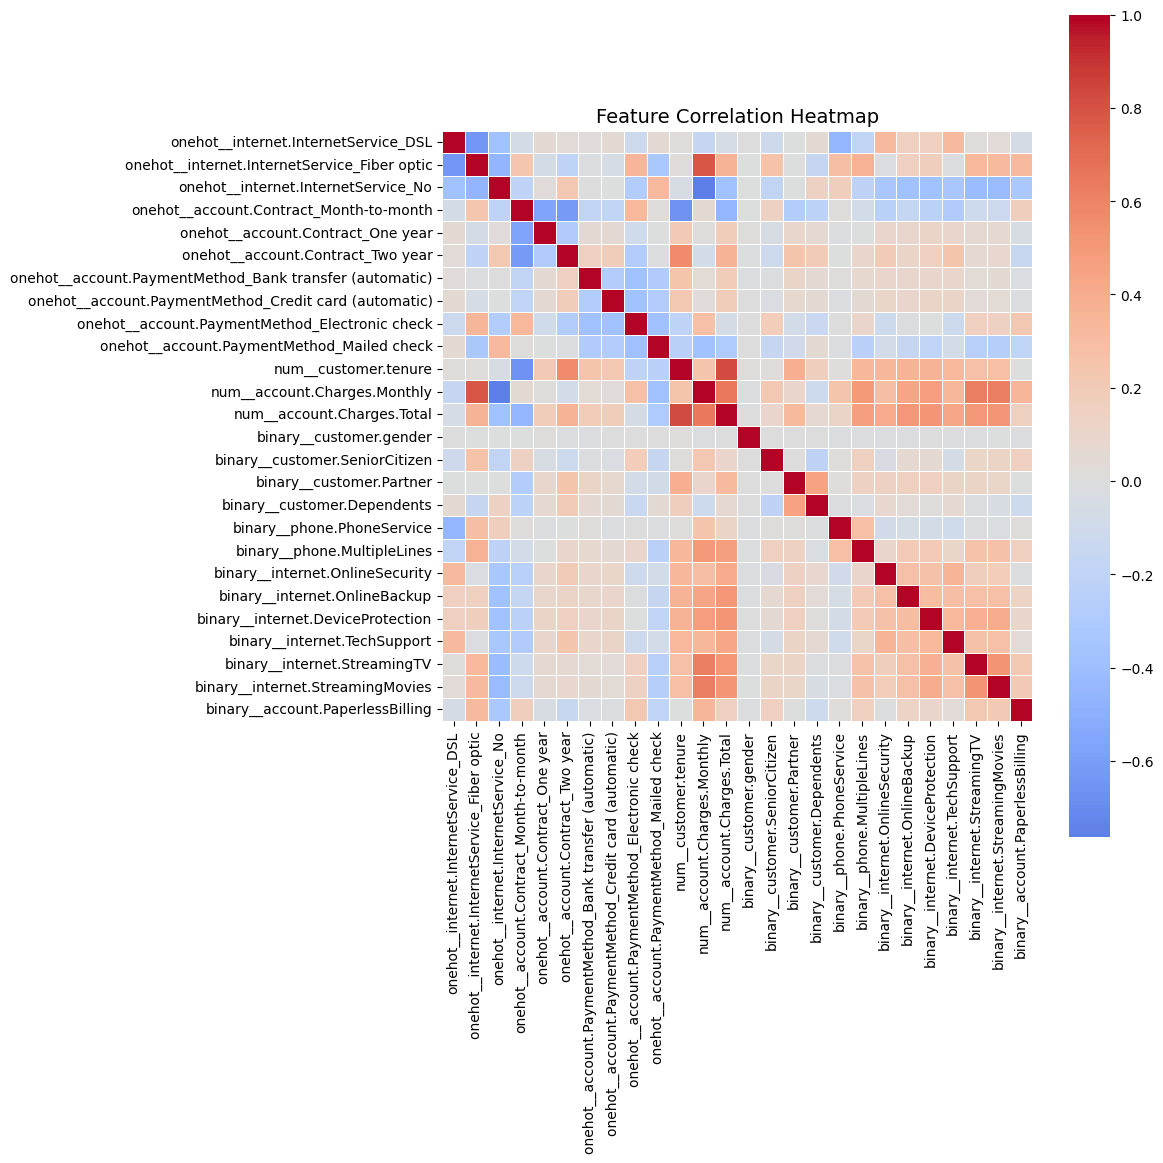

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_heatmap(df, target=None, top_n=None, figsize=(12,12)):
    """
    Plot a correlation heatmap of a dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing numeric features.

    target : str, optional
        Target column to sort correlations by.

    top_n : int, optional
        Number of top correlated features with the target to visualize.

    figsize : tuple
        Size of the plot.
    """

    corr = df.corr()

    # If a target is specified, sort features by correlation
    if target is not None:

        corr_target = corr[target].abs().sort_values(ascending=False)

        if top_n is not None:
            selected_features = corr_target.head(top_n).index
            corr = corr.loc[selected_features, selected_features]

    plt.figure(figsize=figsize)

    sns.heatmap(
        corr,
        #annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5
    )

    plt.title("Feature Correlation Heatmap", fontsize=14)
    plt.tight_layout()
    plt.show()
plot_correlation_heatmap(df_train_processed)

In [ ]:
# ================================
# 10. saving data
# ================================
import joblib


df_train_processed.to_csv("df_train_processed.csv", index=False)

df_test_processed = get_processed_dataframe(pipeline, X_test)
df_test_processed.to_csv("df_test_processed.csv", index=False)

joblib.dump(pipeline, "preprocessing_pipeline.joblib")


In [ ]:
#pipeline = joblib.load("preprocessing_pipeline.joblib")
#X_new_processed = pipeline.transform(X_new)